/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 22 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Số nút giao: 146027
Số đoạn đường: 340544


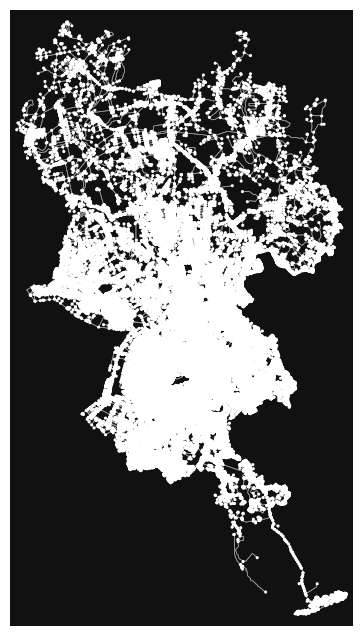

Tổng chiều dài đường (m): 39245995.41
Chiều dài trung bình mỗi đoạn (m): 115.25
Mật độ mạng (km/km²): 13081364631.07


/tmp/ipykernel_2933/1891809595.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = ox.geocode_to_gdf(place_name).geometry.area.iloc[0]  # m²


In [3]:
!pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt


place_name = "Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')


num_nodes = len(G.nodes)
num_edges = len(G.edges)

print("Số nút giao:", num_nodes)
print("Số đoạn đường:", num_edges)


fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.5)


total_length = sum(data['length'] for u, v, data in G.edges(data=True))


avg_length = total_length / num_edges

print("Tổng chiều dài đường (m):", round(total_length, 2))
print("Chiều dài trung bình mỗi đoạn (m):", round(avg_length, 2))


area = ox.geocode_to_gdf(place_name).geometry.area.iloc[0]  # m²
density = (total_length / 1000) / (area / 1e6)

print("Mật độ mạng (km/km²):", round(density, 2))